In [ ]:
from __future__ import unicode_literals, print_function, division
import torch

import torch
import pandas as pd
import random
import time
import string

import pandas as pd

In [478]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Load dataset

In [479]:
import os
import shutil
import kagglehub

In [480]:
my_custom_folder = "../data"
csv_filename = "dataset.csv"
csv_path = os.path.join(my_custom_folder, csv_filename)

# if dataset already exists
if not os.path.exists(csv_path):
    print("Dataset not found locally. Downloading from KaggleHub...")
    default_path = kagglehub.dataset_download("zarajamshaid/language-identification-datasst")
    print("Dataset downloaded to:", default_path)

    # create the folder if it doesn't exist
    os.makedirs(my_custom_folder, exist_ok=True)

    # copy all files from the default path to your custom folder
    for filename in os.listdir(default_path):
        src_path = os.path.join(default_path, filename)
        dst_path = os.path.join(my_custom_folder, filename)
        if os.path.isfile(src_path):
            shutil.copy(src_path, dst_path)

    print(f"Dataset files copied to {my_custom_folder}")
else:
    print(f"Dataset already exists at {csv_path}")

data_dir = my_custom_folder # final dataset destination

Dataset already exists at ../data\dataset.csv


In [481]:
# Load the CSV file
csv_path = os.path.join(data_dir, "dataset.csv")
df = pd.read_csv(csv_path)

df.head()

,Text,language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas på eng the jesuit...,Swedish
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch


In [482]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22000 entries, 0 to 21999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      22000 non-null  object
 1   language  22000 non-null  object
dtypes: object(2)
memory usage: 343.9+ KB


In [483]:
df = df.dropna()

In [484]:
print(f"Dataset shape: {df.shape}")
print(f"Languages: {df['language'].unique()}")

Dataset shape: (22000, 2)
Languages: ['Estonian' 'Swedish' 'Thai' 'Tamil' 'Dutch' 'Japanese' 'Turkish' 'Latin'
 'Urdu' 'Indonesian' 'Portugese' 'French' 'Chinese' 'Korean' 'Hindi'
 'Spanish' 'Pushto' 'Persian' 'Romanian' 'Russian' 'English' 'Arabic']


In [485]:
print(df['language'].value_counts())

language
Estonian      1000
Swedish       1000
Thai          1000
Tamil         1000
Dutch         1000
Japanese      1000
Turkish       1000
Latin         1000
Urdu          1000
Indonesian    1000
Portugese     1000
French        1000
Chinese       1000
Korean        1000
Hindi         1000
Spanish       1000
Pushto        1000
Persian       1000
Romanian      1000
Russian       1000
English       1000
Arabic        1000
Name: count, dtype: int64


there are equal amoung of text examples per language but maybe the etxts are of different sizes

In [486]:
# List of languages to keep
languages_to_keep = [
    "Swedish", "Dutch", "Turkish", "Latin", "Portugese",
    "French", "Spanish", "Romanian", "English"
]

# Filter and sample 1000 rows per language
df = df[df['language'].isin(languages_to_keep)]

In [487]:
df['text_length'] = df['Text'].apply(len)
print(df.groupby('language')['text_length'].describe())

            count     mean         std    min     25%    50%     75%     max
language                                                                    
Dutch      1000.0  337.870  218.977721   41.0  179.00  260.5  422.25  1341.0
English    1000.0  408.452  246.821544  118.0  214.00  335.5  536.25  1301.0
French     1000.0  392.620  252.836607  107.0  197.00  314.5  502.00  1301.0
Latin      1000.0  312.679  211.201804  115.0  174.00  231.5  384.50  1301.0
Portugese  1000.0  381.294  244.793745  115.0  201.00  305.5  489.25  1310.0
Romanian   1000.0  334.297  218.257750  120.0  179.00  253.0  419.00  1260.0
Spanish    1000.0  383.995  235.792899  124.0  211.50  314.0  485.00  1310.0
Swedish    1000.0  316.272  175.295980  128.0  190.00  280.0  384.50  1307.0
Turkish    1000.0  377.937  239.958140  107.0  207.75  300.0  468.25  1313.0


yes, they are

## Create category_lines dictionary (language -> list of texts)

In [488]:
# Get all unique characters for vocabulary
# all_letters = string.ascii_letters + " .,;'"
all_letters = ''.join(sorted(set(''.join(df['Text'].values))))
n_letters = len(all_letters)

# Get all languages
all_categories = sorted(df['language'].unique())
n_categories = len(all_categories)

print(f"Number of letters: {n_letters}")
print(f"Number of categories: {n_categories}")
print(f"Categories: {all_categories}")

Number of letters: 692
Number of categories: 9
Categories: ['Dutch', 'English', 'French', 'Latin', 'Portugese', 'Romanian', 'Spanish', 'Swedish', 'Turkish']


In [489]:
all_letters

' "#$*-<>?[]^`abcdefghijklmnopqrstuvwxyz{|}~\x9d¡£¨ª«°²³´º»½¿×ßàáâãäåæçèéêëìíîïðñòóôõöøùúûüýāăąćčđēęěğġħīıĺļľłńņňŋōŏőœřśşšţťũūŭźżžƒƛǎǐǔșțɑɔəɛɡɪɲʀʁʃʊʒʰʲʼʾʿˆˈˌː̧̯́̃̇͡΄ΐάέήίαβγδεζηθικλμνξοπρςστυφχψωϊόύώабвгдежзийклмнопрстуфхцчшщыьэюяёіїјғқұҷәադեիլղնշովְָּאבדהוזחיכלםמןסעףפצרתأؤإئابةتثجحخدذرزسشصضطعغفقكلمنهوىيَُِپچژکگہیऔकगदधनपमयरलवसहाीुे्ગદનરલવહાીેఉకణదయరి్ಂಗಚಣತದನಮಯರಶಾಿೇ್งซดนบพวสะัาิเດວັაბგევიმნოპრსტფქძᑖᑭᒃᓗᕿᖅតវ្ḏḑḥḩḫṇṣṭẖạảềỉἀἑἡἰἱἴὁὅὑὰὶὸᾶῆῖῥῦῶ\u200b\u200e\u200f‐‑–—‘’“”„‟†•…\u202c′″⁄\u2060€ℝℤ→↦∅−∞∪∼≠≤⊕☄♁♯あおさのはぶべまや一三上主九二人代仲伊伝传何健光六冷刘劉动包化北卑南取古叫史吳周哥噠器回國園地城堅外天女姓姻婚孤孫安宋宮家小少居山峡川市府座康張思恵悠慶懨成戸拓掖撒敬日旧明春昭显時晉普暦曹有服朝本李村東林柄梁棋植楊武汗沢治法泡洙浩渕澤灰為父物特瓦甘生画畑発白盆盘盛盲省県石社祁神祿禅禪米粛粟經緑羅義翰老耶育胡臨臺舍舒舟英茹蔣藤血西計講護豪資跋路辦运連達郎部都酒野镇長門閘關陳靑須馬駅魏魔鮮鳥齊고광담대동드리백산수아언와원이인장주청춘키ﬁﬂ\ufeff'

In [490]:
category_lines = {}
for language in all_categories:
    category_lines[language] = df[df['language'] == language]['Text'].tolist()

In [491]:
category_lines

{'Dutch': ['de spons behoort tot het geslacht haliclona en behoort tot de familie chalinidae de wetenschappelijke naam van de soort werd voor het eerst geldig gepubliceerd in  door kudelin',
  'de prinses was als erfgename van polen een goede partij voor de boheemse koning wenceslaus ii in  werd ze naar bohemen gebracht en werd er opgevoed door de tante van wenceslaus ii in  huwde de toen -jarige richezza met de -jarige wenceslaus ii die naast koning van bohemen in  ook koning van polen was geworden vervolgens werd richezza door hendrik van würben de bisschop van breslau tot koningin-gemalin van bohemen gekroond en nam ze voortaan de naam elisabeth aan in  baarde richezza een dochter agnes de verwachte zoon die de poolse kroon zou erven kwam er niet meer omdat wenceslaus ii in juni  stierf hierdoor werd richezza op slechts -jarige leeftijd al weduwe',
  'deliège werd gemeenteraadslid  en burgemeester - van binche hij was ook provincieraadslid van  tot  hij nam initiatieven voor de hero

## Helper functions to convert text and categories to tensors

In [ ]:

def letterToIndex(letter):
    return all_letters.find(letter)

def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# keep all texts to a fixed length up to 100 characters to remove bias
MAX_LENGTH = 50
def lineToTensor(line):
    line = line[:MAX_LENGTH].ljust(MAX_LENGTH)
    tensor = torch.zeros(MAX_LENGTH, 1, n_letters)
    for li, letter in enumerate(line):
        if letter in all_letters:
            tensor[li][0][letterToIndex(letter)] = 1

    return tensor

def categoryToTensor(category):
    return torch.tensor([all_categories.index(category)], dtype=torch.long)

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = categoryToTensor(category)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor


print("\nTesting randomTrainingExample() functions:")
for i in range(3):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print(f'category = {category} / line = {line[:30]}...')
    print(f'category_tensor shape: {category_tensor.shape}')
    print(f'line_tensor shape: {line_tensor.shape}')
    print('-' * 40)

# get category from output
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

# Time tracking function
def timeSince(since):
    now = time.time()
    s = now - since
    m = int(s / 60)
    s -= m * 60
    return f'{m}m {s:.0f}s'


Testing randomTrainingExample() functions:
category = Dutch / line = van augustus  tot  april  was ...
category_tensor shape: torch.Size([1])
line_tensor shape: torch.Size([50, 1, 692])
----------------------------------------
category = Latin / line = carolus gounod natus lutetiae ...
category_tensor shape: torch.Size([1])
line_tensor shape: torch.Size([50, 1, 692])
----------------------------------------
category = French / line = la présence au début du xve si...
category_tensor shape: torch.Size([1])
line_tensor shape: torch.Size([50, 1, 692])
----------------------------------------


# DataLoader for batch trainning

In [493]:
from torch.utils.data import Dataset, DataLoader

class LanguageDataset(Dataset):
    def __init__(self, df):
        self.texts = df['Text'].tolist()
        self.labels = df['language'].tolist()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        line = self.texts[idx]
        label = self.labels[idx]
        line_tensor = lineToTensor(line)
        category_tensor = all_categories.index(label)  # return as int, not tensor
        return line_tensor, category_tensor

batch_size = 32
dataset = LanguageDataset(df)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

## LSTM model

In [494]:
class LSTMLanguageID(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2, dropout=0.3):
        super(LSTMLanguageID, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers=num_layers, 
            dropout=dropout if num_layers > 1 else 0, batch_first=False
        )
        self.fc = nn.Linear(hidden_size, output_size)
        self.logsoftmax = nn.LogSoftmax(dim=1)
    
    def forward(self, x, hidden):
        lstm_out, hidden = self.lstm(x, hidden)
        output = lstm_out[-1]
        output = self.fc(output)
        output = self.logsoftmax(output)
        return output, hidden
    
    def initHidden(self, batch_size=1):
        # (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h0, c0)

# Training function

In [495]:
def train_step(category_tensor, line_tensor, optimizer, criterion, model):
    model.train()
    hidden = model.initHidden()
    model.zero_grad()
    
    # Move tensors to device
    category_tensor = category_tensor.to(device)
    line_tensor = line_tensor.to(device)
    
    # Forward pass
    output, hidden = model(line_tensor, hidden)
    
    # Calculate loss
    # target = torch.topk(category_tensor, 1).indices.view(-1)
    loss = criterion(output, category_tensor.to(device))
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    return output, loss.item()


# Training

In [496]:
criterion = nn.NLLLoss()
learning_rate = 0.0005
hidden_size = 256  # or 512
num_layers = 2     # or 3
dropout = 0.3

model = LSTMLanguageID(n_letters, hidden_size, n_categories, num_layers=num_layers, dropout=dropout)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"\nModel created with:")
print(f"Input size: {n_letters}")
print(f"Hidden size: {hidden_size}")
print(f"Output size: {n_categories}")


Model created with:
Input size: 692
Hidden size: 256
Output size: 9


In [497]:
#### DELETE THIS BLOCK AFTER DEBUGGING ####

# ...existing code...
# For debugging, try this before full training:
small_df = df.sample(20, random_state=42)
small_dataset = LanguageDataset(small_df)
small_dataloader = DataLoader(small_dataset, batch_size=4, shuffle=True)
for epoch in range(10):
    avg_loss = train_batch(model, small_dataloader, optimizer, criterion, device)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
# ...existing code...

Epoch 1, Loss: 2.2050
Epoch 2, Loss: 2.1930
Epoch 3, Loss: 2.1875
Epoch 4, Loss: 2.1823
Epoch 5, Loss: 2.1735
Epoch 6, Loss: 2.1653
Epoch 7, Loss: 2.1553
Epoch 8, Loss: 2.1529
Epoch 9, Loss: 2.1448
Epoch 10, Loss: 2.1283


Epoch 1/10, Loss: 1.9109
Epoch 2/10, Loss: 1.2940
Epoch 3/10, Loss: 1.0375
Epoch 4/10, Loss: 0.9656
Epoch 5/10, Loss: 0.9717
Epoch 6/10, Loss: 1.0519
Epoch 7/10, Loss: 0.8986
Epoch 8/10, Loss: 0.8474
Epoch 9/10, Loss: 0.8008
Epoch 10/10, Loss: 0.7809


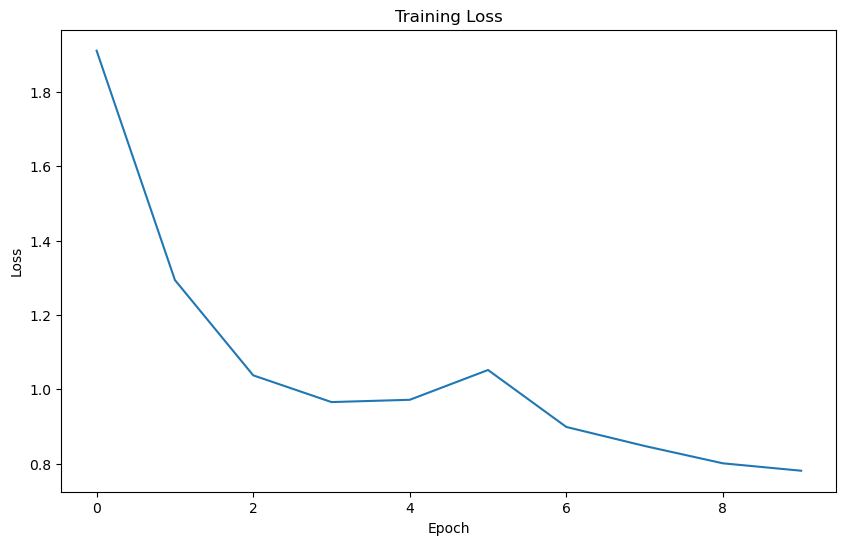

In [498]:
def train_batch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for line_tensors, category_tensors in dataloader:
        # line_tensors: (batch, seq, 1, n_letters) -> (seq, batch, n_letters)
        line_tensors = line_tensors.squeeze(2).permute(1, 0, 2).to(device)
        category_tensors = category_tensors.to(device)
        batch_size = line_tensors.shape[1]
        hidden = model.initHidden(batch_size)
        optimizer.zero_grad()
        output, hidden = model(line_tensors, hidden)
        loss = criterion(output, category_tensors.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

n_epochs = 10   
all_losses = []
for epoch in range(n_epochs):
    avg_loss = train_batch(model, dataloader, optimizer, criterion, device)
    all_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}") 

plt.figure(figsize=(10, 6))
plt.plot(all_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Evaluation function

In [499]:
def evaluate(line_tensor, model):
    model.eval()
    hidden = model.initHidden()
    line_tensor = line_tensor.to(device)
    
    with torch.no_grad():
        output, hidden = model(line_tensor, hidden)
    
    return output

# Prediction function

In [527]:
def predict(input_line, n_predictions=3):
    print(f'\n> {input_line}')
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line), model)
        
        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []
        
        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print(f'({value:.2f}) {all_categories[category_index]}')
            predictions.append([value, all_categories[category_index]])
    
    return predictions

# test the model with sample texts
print("\n" + "="*50)
print("TESTING PREDICTIONS")
print("="*50)

test_samples = [
    "This sentence was writtnen in a language you should be able to identify", # English
    "Denna mening skrevs på ett språk som du borde kunna identifiera", # Swedish
    "Cette phrase a été écrite dans une langue que vous devriez pouvoir identifier", # French
    "Deze zin is geschreven in een taal die je zou moeten kunnen identificeren", # Dutch
    "Bu cümle, tanımlayabileceğiniz bir dilde yazılmıştır.", # Turkish
    "Esta frase fue escrita en un idioma que deberías poder identificar.",] # Spanish

for sample in test_samples:
    predict(sample)




TESTING PREDICTIONS

> This sentence was writtnen in a language you should be able to identify
(-0.36) English
(-2.27) Dutch
(-2.33) Latin

> Denna mening skrevs på ett språk som du borde kunna identifiera
(-0.00) Swedish
(-6.88) Dutch
(-7.55) Turkish

> Cette phrase a été écrite dans une langue que vous devriez pouvoir identifier
(-0.05) French
(-4.11) Romanian
(-4.17) Latin

> Deze zin is geschreven in een taal die je zou moeten kunnen identificeren
(-0.70) Dutch
(-1.46) English
(-2.62) Portugese

> Bu cümle, tanımlayabileceğiniz bir dilde yazılmıştır.
(-0.00) Turkish
(-7.67) Swedish
(-8.51) Latin

> Esta frase fue escrita en un idioma que deberías poder identificar.
(-0.63) Portugese
(-0.80) Spanish
(-5.13) Romanian


In [512]:
test_text = "Jag älskar att programmera och lära mig nya språk"
predictions = predict(test_text, 5)

print(f"\nBest prediction for '{test_text}': {predictions[0][1]} (confidence: {predictions[0][0]:.2f})")


> Jag älskar att programmera och lära mig nya språk
(-0.00) Swedish
(-6.35) Dutch
(-7.34) Turkish
(-7.61) French
(-8.66) Portugese

Best prediction for 'Jag älskar att programmera och lära mig nya språk': Swedish (confidence: -0.00)
